In [1]:
#LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [2]:
#DATASETS
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [3]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
test.head()


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [5]:
sample_submission.head()

,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76


In [6]:
#BASIC INSPECTION
print("Train shape:", train.shape)
print("Test shape:",test.shape)
print("Sample Submission shape:",sample_submission.shape)

Train shape: (6818, 13)
Test shape: (1705, 12)
Sample Submission shape: (1705, 2)


In [7]:
print("Train columns:", train.columns)
print(".................................................")
print("Test columns:",test.columns)
print("..................................................")
print("Sample Submission columns:",sample_submission.columns)

Train columns: Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format',
       'total_sales'],
      dtype='str')
.................................................
Test columns: Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format'],
      dtype='str')
..................................................
Sample Submission columns: Index(['id', 'total_sales'], dtype='str')


In [8]:
train.info()
print(".................................................")
test.info()
print("..................................................")
sample_submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   str    
 1   product_code         6818 non-null   str    
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   str    
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   str    
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   str    
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   str    
 10  store_location_tier  6818 non-null   str    
 11  store_format         6818 non-null   str    
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 1.2 MB
.................................................
<class 'pandas.DataFrame'>
RangeIndex: 1705 en

In [9]:
#CLEAN PRODUCT CATEGORY
train["product_category"] =(train["product_category"].str.strip().str.lower())

test["product_category"] =(test["product_category"].str.strip().str.lower())

print("Unique categories:",train["product_category"].nunique())

Unique categories: 16


In [10]:
#DATA QUALITY
#Missing Values
missing = pd.DataFrame({"Train_missing":train.isna().sum(),
                        "Test_missing": test.isna().sum()})
missing[missing.sum(axis=1) >0]

,Train_missing,Test_missing
product_weight_kg,1225,306.0
store_size,1919,491.0


In [11]:
#Duplicates
print("Train duplicates:", train.duplicated().sum())
print("Test duplicates:", test.duplicated().sum())

print("Duplicates IDs in train:", train["id"].duplicated().sum())
print("Duplicates IDs in test:", test["id"].duplicated().sum())

Train duplicates: 0
Test duplicates: 0
Duplicates IDs in train: 0
Duplicates IDs in test: 0


In [12]:
#Unique Values
unique_summary = pd.DataFrame({"dtypes":train.dtypes,
                               "unique":train.nunique(),
                               "missing":train.isna().sum()
                               })
unique_summary

,dtypes,unique,missing
id,str,6818,0
product_code,str,1555,0
product_weight_kg,float64,4675,1225
fat_content,str,2,0
shelf_visibility,float64,1732,0
product_category,str,16,0
product_price,float64,5818,0
store_code,str,10,0
store_age_years,int64,9,0
store_size,str,3,1919


In [13]:
#Desciptive Analysis
display(train.describe(include="all").T)
print(".................................................")
display(test.describe(include="all").T)
print(".................................................")
display(sample_submission.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6818,6818,row_00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_code,6818,1555,PRD-YZB4K8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_kg,5593.0,NaN,NaN,NaN,12.850876,4.646542,4.482,8.75,12.647,16.894,21.883
fat_content,6818,2,Low Fat,4425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shelf_visibility,6818.0,NaN,NaN,NaN,0.065527,0.051566,0.0,0.0266,0.0532,0.0934,0.3201
product_category,6818,16,fruits and vegetables,1006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_price,6818.0,NaN,NaN,NaN,140.473623,62.413513,31.11,93.28,142.065,185.9875,273.04
store_code,6818,10,STORE-YLW,754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_age_years,6818.0,NaN,NaN,NaN,34.178205,8.384574,23.0,28.0,33.0,45.0,47.0
store_size,4899,3,Medium,2218,NaN,NaN,NaN,NaN,NaN,NaN,NaN


.................................................


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1705,1705,row_00009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_code,1705,1082,PRD-02NFGI,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_kg,1399.0,NaN,NaN,NaN,12.86596,4.647713,4.693,8.753,12.617,16.9155,21.98
fat_content,1705,2,Low Fat,1092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shelf_visibility,1705.0,NaN,NaN,NaN,0.068491,0.051721,0.0,0.0302,0.0564,0.0984,0.302
product_category,1705,16,snack foods,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_price,1705.0,NaN,NaN,NaN,143.06949,61.888692,31.98,96.56,144.63,185.21,270.87
store_code,1705,10,STORE-89Z,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_age_years,1705.0,NaN,NaN,NaN,34.127859,8.32265,23.0,28.0,33.0,45.0,47.0
store_size,1214,3,Medium,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN


.................................................


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1705,1705,row_00009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sales,1705.0,NaN,NaN,NaN,2174.76,0.0,2174.76,2174.76,2174.76,2174.76,2174.76


In [14]:
#IDENTIFY CATEGORICAL AND NUMERIC COLUMNS
cat_cols = train.select_dtypes(exclude=np.number).columns.tolist()
num_cols = train.select_dtypes(include=np.number).columns.tolist()
print("Categorical features:", cat_cols)
print("Numerical features:", num_cols)


Categorical features: ['id', 'product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
Numerical features: ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']


In [15]:
#TARGET STATISTICS
train["total_sales"].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

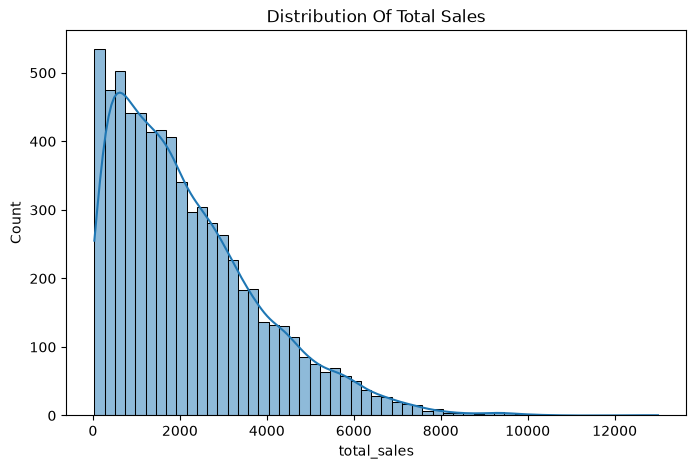

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(train["total_sales"],kde=True)
plt.title("Distribution Of Total Sales")
plt.show()

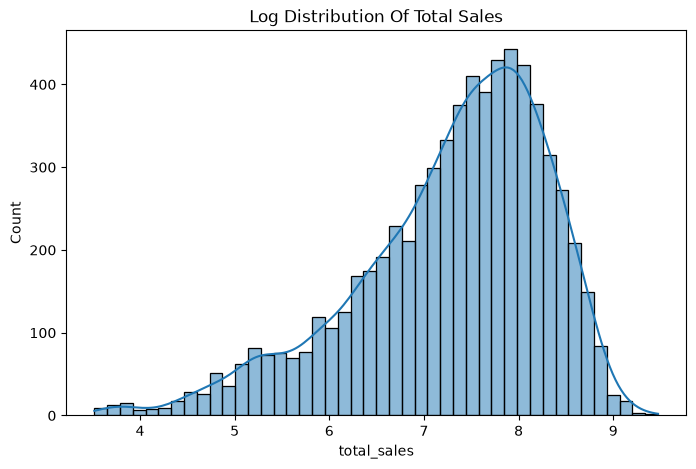

In [17]:
#Log Distribution
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(train["total_sales"]),kde=True)
plt.title("Log Distribution Of Total Sales")
plt.show()

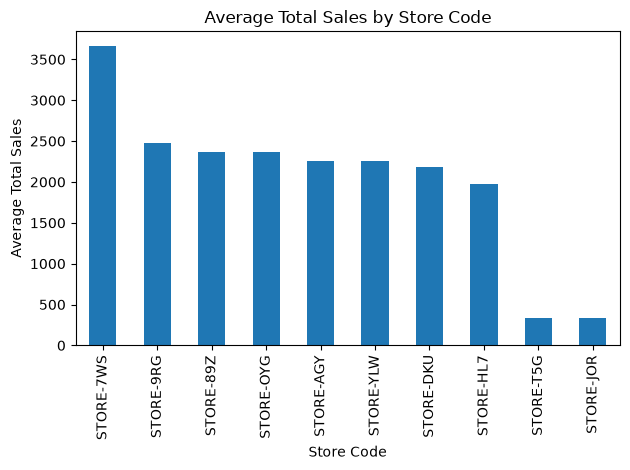

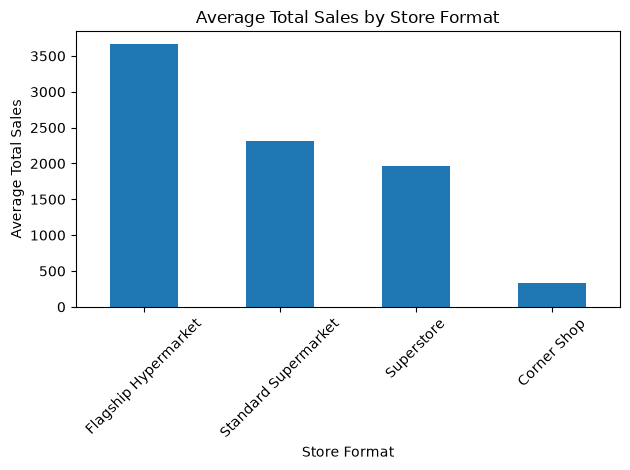

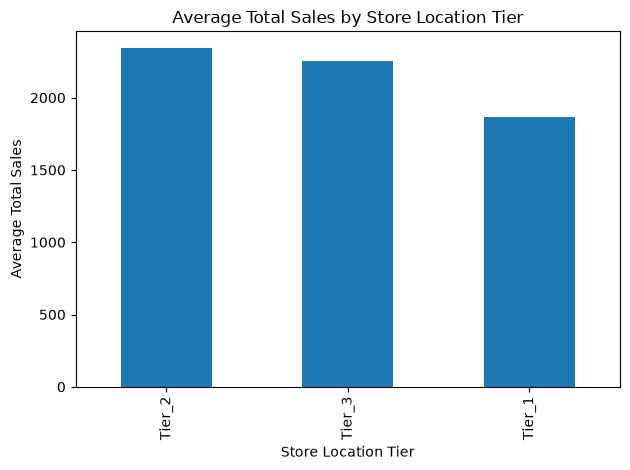

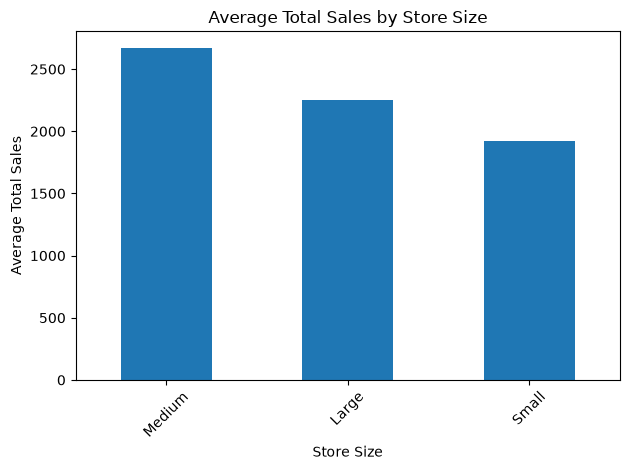

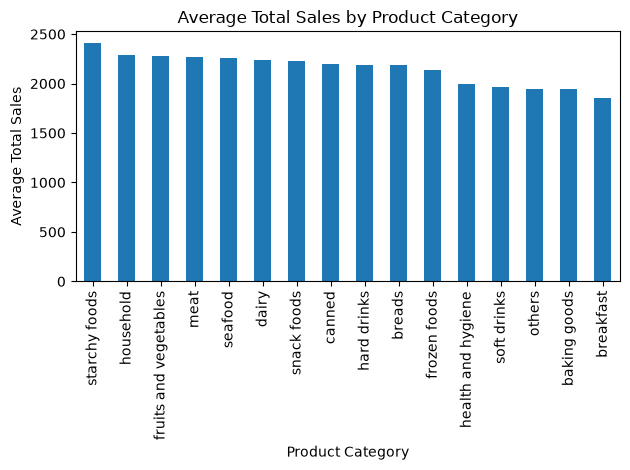

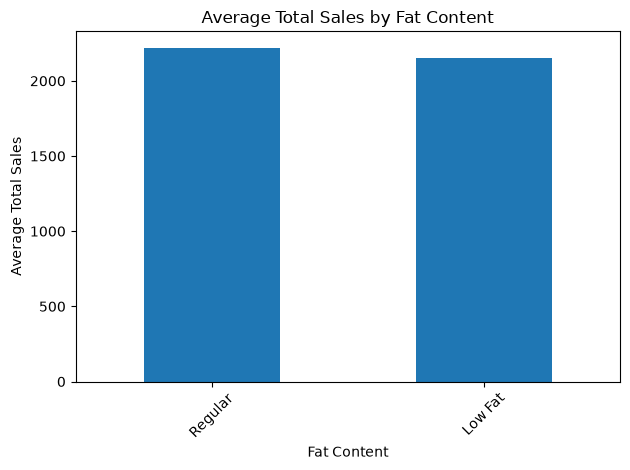

In [18]:
#RELATIONSHIPS WITH TARGET - CATEGORICAL FEATURES

train.groupby("store_code")["total_sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Sales by Store Code")
plt.xlabel("Store Code")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

train.groupby("store_format")["total_sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Sales by Store Format")
plt.xlabel("Store Format")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

train.groupby("store_location_tier")["total_sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Sales by Store Location Tier")
plt.xlabel("Store Location Tier")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

train.groupby("store_size")["total_sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Sales by Store Size")
plt.xlabel("Store Size")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

train.groupby("product_category")["total_sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

train.groupby("fat_content")["total_sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Sales by Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
train.groupby("store_code")["total_sales"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean",ascending=False)

,count,mean,median,std
store_code,,,,
STORE-7WS,748,3660.182219,3348.085,2070.097702
STORE-9RG,752,2479.168098,2139.320,1553.797046
STORE-89Z,728,2365.926745,2003.490,1518.177714
STORE-OYG,744,2365.833656,2018.895,1566.741909
STORE-AGY,748,2254.890120,1998.725,1501.401983
STORE-YLW,754,2253.950690,1902.455,1488.222137
STORE-DKU,736,2177.136481,1863.030,1446.586133
STORE-HL7,742,1971.661954,1622.170,1397.518220
STORE-T5G,427,338.326651,260.820,254.819146


In [20]:
train.groupby("store_format")["total_sales"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean",ascending=False)

,count,mean,median,std
store_format,,,,
Flagship Hypermarket,748,3660.182219,3348.085,2070.097702
Standard Supermarket,4462,2316.319677,1998.270,1515.508566
Superstore,742,1971.661954,1622.170,1397.518220
Corner Shop,866,336.353868,252.150,265.203584


In [21]:
train.groupby("store_location_tier")["total_sales"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean",ascending=False)

,count,mean,median,std
store_location_tier,,,,
Tier_2,2232,2341.795296,2014.52,1528.102355
Tier_3,2677,2254.114400,1794.26,1886.265993
Tier_1,1909,1868.171278,1455.21,1563.302794


In [22]:
#RELATIONSHIPS WITH TARGET - NUMERIC FEATURES
train[num_cols].corr()["total_sales"].sort_values(ascending=False)


total_sales          1.000000
product_price        0.569833
store_age_years      0.039443
product_weight_kg    0.015532
shelf_visibility    -0.118124
Name: total_sales, dtype: float64

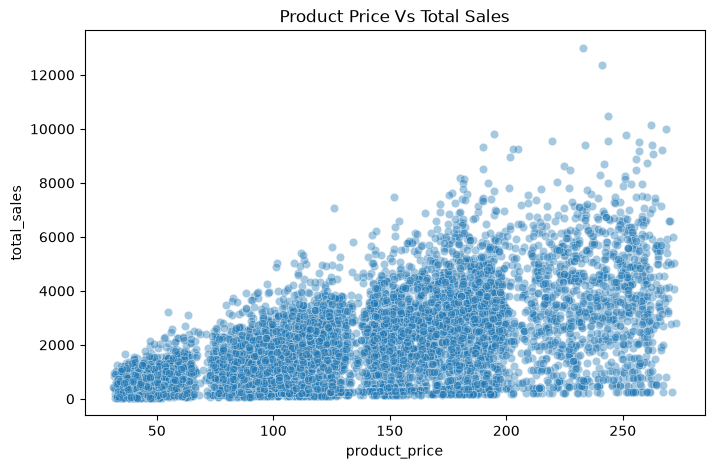

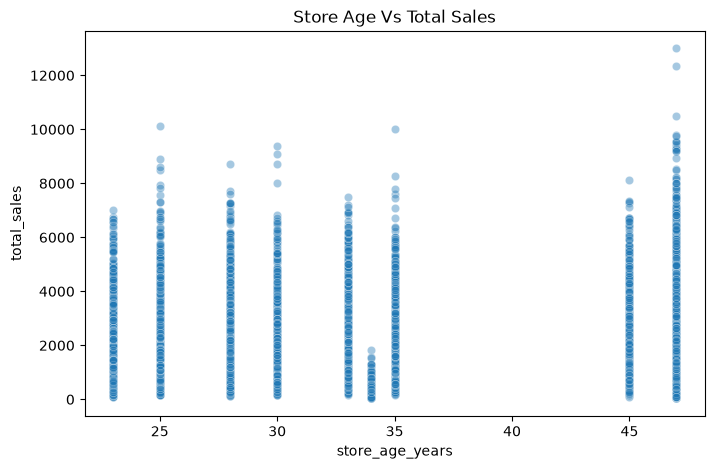

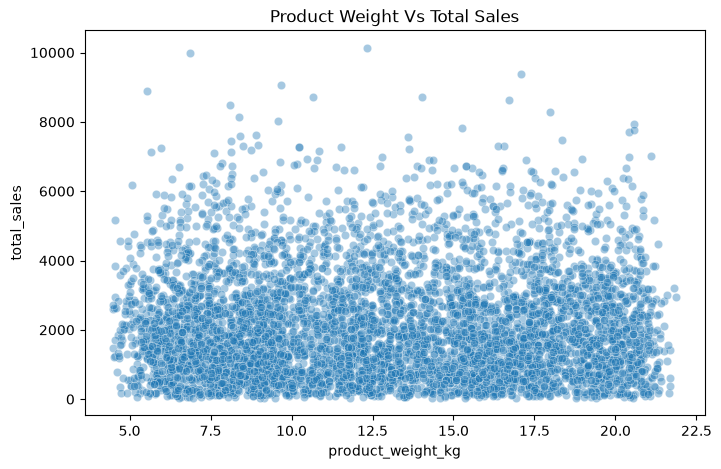

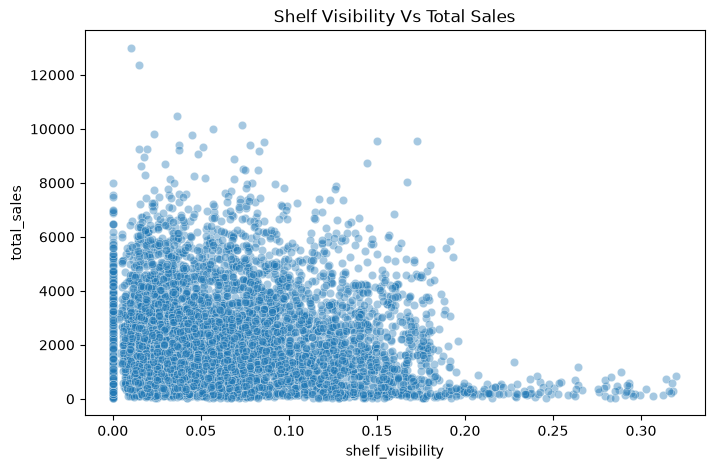

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=train, x="product_price", y="total_sales", alpha=0.4)
plt.title("Product Price Vs Total Sales")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=train, x="store_age_years", y="total_sales", alpha=0.4)
plt.title("Store Age Vs Total Sales")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=train, x="product_weight_kg", y="total_sales", alpha=0.4)
plt.title("Product Weight Vs Total Sales")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=train, x="shelf_visibility", y="total_sales", alpha=0.4)
plt.title("Shelf Visibility Vs Total Sales")
plt.show()

In [24]:
#STRUCTURE CHECK
#Product Repetition
product_counts = train["product_code"].value_counts()

print("Unique products:", product_counts.size)
print("Average rows per product:", product_counts.mean())
print("Maximum rows for one products:", product_counts.max())

product_counts.describe()

Unique products: 1555
Average rows per product: 4.384565916398714
Maximum rows for one products: 9


count    1555.000000
mean        4.384566
std         1.556328
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: count, dtype: float64

In [25]:
train.groupby("product_code")["total_sales"].agg(
    ["count", "mean", "std"]
).sort_values("count", ascending=False).head(15)

,count,mean,std
product_code,,,
PRD-YZB4K8,9,961.012222,581.912637
PRD-8A5PN4,8,3464.262500,2274.339733
PRD-ZE84LM,8,1436.472500,850.666649
PRD-9KE7J2,8,3018.007500,2128.509420
PRD-WJIQXP,8,2524.891250,2754.716264
PRD-YLAH3X,8,1692.810000,795.162766
PRD-3I603D,8,4565.187500,811.853976
PRD-UDD467,8,2151.977500,1556.086604
PRD-8INI8M,8,1563.003750,960.419980


In [26]:
#Store Consistency
store_structure = train.groupby("store_code").agg({
    "store_age_years": "nunique",
    "store_size": "nunique",
    "store_location_tier": "nunique",
    "store_format": "nunique",
})

store_structure

,store_age_years,store_size,store_location_tier,store_format
store_code,,,,
STORE-7WS,1,1,1,1
STORE-89Z,1,1,1,1
STORE-9RG,1,1,1,1
STORE-AGY,1,1,1,1
STORE-DKU,1,0,1,1
STORE-HL7,1,1,1,1
STORE-JOR,1,0,1,1
STORE-OYG,1,0,1,1
STORE-T5G,1,1,1,1


In [27]:
#Product Consistency
product_structure = train.groupby("product_code").agg({
    "product_weight_kg": "nunique",
    "fat_content": "nunique",
    "product_category": "nunique",
    "product_price": "nunique",
})

product_structure.describe()

,product_weight_kg,fat_content,product_category,product_price
count,1555.000000,1555.0,1555.0,1555.000000
mean,3.587138,1.0,1.0,4.376206
std,1.394728,0.0,0.0,1.551957
min,0.000000,1.0,1.0,1.000000
25%,3.000000,1.0,1.0,3.000000
50%,4.000000,1.0,1.0,4.000000
75%,5.000000,1.0,1.0,5.000000
max,8.000000,1.0,1.0,9.000000


In [28]:
#TRAIN/TEST OVERLAP
print("Products in test also found in train:", test["product_code"]
      .isin(train["product_code"]).mean())

print("Stores in test also found in train:", test["store_code"]
      .isin(train["store_code"]).mean())

print("Categories in test also found in train:", test["product_category"]
      .isin(train["product_category"]).mean())

Products in test also found in train: 0.9964809384164223
Stores in test also found in train: 1.0
Categories in test also found in train: 1.0


In [29]:
#FEATURE ENGINEERING
#Fill missing store size using the store's known size
store_size_map = (train.dropna(subset=["store_size"])
                  .groupby("store_code")["store_size"].first())

train["store_size"] = train["store_size"].fillna(
    train["store_code"].map(store_size_map))

test["store_size"] = test["store_size"].fillna(
    test["store_code"].map(store_size_map))

print("Train missing store_size:", train["store_size"].isna().sum())
print("Test missing store_size:", test["store_size"].isna().sum())

Train missing store_size: 1919
Test missing store_size: 491


In [30]:
#Recover missing product weight
product_weight_map = (train.dropna(subset=["product_weight_kg"])
                  .groupby("product_code")["product_weight_kg"].median())

train["product_weight_kg"] = train["product_weight_kg"].fillna(
    train["product_code"].map(product_weight_map))

test["product_weight_kg"] = test["product_weight_kg"].fillna(
    test["product_code"].map(product_weight_map))

print("Train missing product_weight:", train["product_weight_kg"].isna().sum())
print("Test missing product_weight:", test["product_weight_kg"].isna().sum())

Train missing product_weight: 8
Test missing product_weight: 6


In [31]:
#Price Per Kilogram
train["price_per_kg"] = (train["product_price"]/
train["product_weight_kg"].replace(0, np.nan))

test["price_per_kg"] = (test["product_price"]/
test["product_weight_kg"].replace(0, np.nan))

In [32]:
#Log Price
train["log_price"] = np.log1p(train["product_price"])
test["log_price"] = np.log1p(test["product_price"])

In [33]:
#INTERACTIONS
for df in [train, test]:
    df["store_category"] = (df["store_code"] + "_" + df["product_category"])
    df["format_category"] = (df["store_format"] + "_" + df["product_category"])
    df["store_location_format"] = (
        df["store_location_tier"] + "_" + df["store_format"])

In [34]:
#MODELLING FEATURE LIST
features = [
    "product_code","product_weight_kg","fat_content","shelf_visibility",
    "product_category","product_price","store_code","store_age_years",
    "store_size","store_location_tier","store_format","price_per_kg",
    "log_price","store_category","format_category","store_location_format"]

X = train[features]
y = train ["total_sales"]

X_test = test[features]

print("Number of features:",len(features))

Number of features: 16


In [35]:
print(train.groupby("store_code")["store_size"]
      .agg(["count","nunique","first"]))

            count  nunique   first
store_code                        
STORE-7WS     748        1  Medium
STORE-89Z     728        1  Medium
STORE-9RG     752        1   Small
STORE-AGY     748        1   Large
STORE-DKU       0        0     NaN
STORE-HL7     742        1  Medium
STORE-JOR       0        0     NaN
STORE-OYG       0        0     NaN
STORE-T5G     427        1   Small
STORE-YLW     754        1   Small


In [36]:
print(test["store_code"].isin(train["store_code"]).mean())

1.0


In [37]:
#MODEL LIBs
import importlib.util
print("CatBoost:", importlib.util.find_spec("catboost"))
print("XGBoost:", importlib.util.find_spec("xgboost"))
print("LightGBM:", importlib.util.find_spec("lightgbm"))

CatBoost: ModuleSpec(name='catboost', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000020AFCD776D0>, origin='c:\\Users\\USER\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\catboost\\__init__.py', submodule_search_locations=['c:\\Users\\USER\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\catboost'])
XGBoost: ModuleSpec(name='xgboost', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000020AFCD776D0>, origin='c:\\Users\\USER\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\xgboost\\__init__.py', submodule_search_locations=['c:\\Users\\USER\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\xgboost'])
LightGBM: ModuleSpec(name='lightgbm', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000020AFCD776D0>, origin='c:\\Users\\USER\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\lightgbm\\__init__.py', submodule_search_locations=['c:\\Users\\USER\\AppData

In [38]:
#CATBOOST DATA PREPARATION
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

X = train[features].copy()
y = train["total_sales"].copy()
X_test = test[features].copy()

cat_cols = X.select_dtypes(include="object").columns.tolist()

#CatBoost requires catgorical values to be strings
for col in cat_cols:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Categorical features:", cat_cols)

Training shape: (6818, 16)
Test shape: (1705, 16)
Categorical features: ['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format', 'store_category', 'format_category', 'store_location_format']


In [39]:
#VERIFY
print("Missing categorical values in train:",
      X[cat_cols].isna().sum().sum())

print("Missing categorical values in test:",
      X_test[cat_cols].isna().sum().sum())

Missing categorical values in train: 0
Missing categorical values in test: 0


In [40]:
#5-Fold CV CatBoost Baseline
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=1000,learning_rate=0.05,depth=7,loss_function="RMSE",
        random_seed=RANDOM_STATE, verbose=False)
    
    model.fit(X_train, y_train, cat_features = cat_cols)
    predictions = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    rmse_scores.append(rmse)

    print(f"Fold {fold} RMSE:{rmse:.4f}")

print("\nMean CV RMSE:", np.mean(rmse_scores))
print("std CV RMSE:", np.std(rmse_scores))

Fold 1 RMSE:1093.9911
Fold 2 RMSE:1073.6717
Fold 3 RMSE:1118.9651
Fold 4 RMSE:1131.3339
Fold 5 RMSE:1101.5215

Mean CV RMSE: 1103.8966608749583
std CV RMSE: 19.985845364041648


In [41]:
#5-Fold CV CatBoost Baseline(2ND TESTING)
#kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
#rmse_scores = []

#for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    #X_train = X.iloc[train_idx].copy()
    #X_valid = X.iloc[valid_idx].copy()

    #y_train = y.iloc[train_idx]
    #y_valid = y.iloc[valid_idx]

    #TEMPORARY DATAFRAME FOR CALCULATING HISTORICAL TARGET STATISTICS
    #train_stats = X_train.copy()
    #train_stats["total_sales"] = y_train.values

    #1. PRODUCT MEAN SALES
    #product_mean = train_stats.groupby("product_code")["total_sales"].mean()
    #X_train["product_mean_sales"] = X_train["product_code"].map(product_mean)
    #X_valid["product_mean_sales"] = X_valid["product_code"].map(product_mean)

    #2. STORE MEAN SALES
    #store_mean = train_stats.groupby("store_code")["total_sales"].mean()
    #X_train["store_mean_sales"] = X_train["store_code"].map(store_mean)
    #X_valid["store_mean_sales"] = X_valid["product_code"].map(store_mean)

    #3. STORE + CATEGORY MEAN SALES
    #store_category_mean = train_stats.groupby(
        #["store_code","product_category"])["total_sales"].mean()
    #X_train["store_category_mean_sales"] = [
        #store_category_mean.get((store, category), np.nan)
        #for store, category in zip(
            #X_train["store_code"],X_train["product_category"])]
    
    #X_valid["store_category_mean_sales"] = [
        #store_category_mean.get((store, category), np.nan)
        #for store, category in zip(
            #X_valid["store_code"], X_valid["product_category"])]

    #FILL ANY UNSEEN COMBINATIONS WITH OVERALL TRAINING MEAN
    #overall_mean = y_train.mean()
    #for col in [
        #"product_mean_sales", "store_mean_sales", "store_category_mean_sales"]:
        #X_train[col] = X_train[col].fillna(overall_mean)
        #X_valid[col] = X_valid[col].fillna(overall_mean)

    #TRAIN CATBOOST
    #model = CatBoostRegressor(
        #iterations=1000,learning_rate=0.05,depth=7,loss_function="RMSE",
        #random_seed=RANDOM_STATE, verbose=False)
    
    #model.fit(X_train, y_train, cat_features = cat_cols)
    #predictions = model.predict(X_valid)
    #rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    #rmse_scores.append(rmse)

    #print(f"Fold {fold} RMSE:{rmse:.4f}")

#print("\nMean CV RMSE:", np.mean(rmse_scores))
#print("std CV RMSE:", np.std(rmse_scores))

In [42]:
#Experiment 1 - CatBoost Depth Tuning
depth_results = []
for current_depth in [6,7,8,9]:
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rmse_scores = []

    for train_idx, valid_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostRegressor(
        iterations=1000,learning_rate=0.05,depth=current_depth,
        loss_function="RMSE",random_seed=RANDOM_STATE, verbose=False)

        model.fit(X_train, y_train, cat_features = cat_cols)
        predictions = model.predict(X_valid)
        rmse_scores.append(np.sqrt(mean_squared_error(y_valid, predictions)))

    mean_rmse = np.mean(rmse_scores)
    depth_results.append({
        "depth":current_depth,"mean_rmse":mean_rmse,
        "std_rmse":np.std(rmse_scores)})

    print(f"Depth {current_depth}:" f"Mean CV RMSE = {mean_rmse:.4f}")

depth_results_df = pd.DataFrame(depth_results)

print("\nCATBOOST DEPTH COMPARISON:")
display(depth_results_df)
best_depth = depth_results_df.loc[
    depth_results_df["mean_rmse"].idxmin(),"depth"]

best_rmse = depth_results_df["mean_rmse"].min()

print(f"\nBest Depth: {int(best_depth)}")
print(f"Best CV RMSE:{best_rmse:.4f}")

Depth 6:Mean CV RMSE = 1102.2516
Depth 7:Mean CV RMSE = 1103.8967
Depth 8:Mean CV RMSE = 1105.4313
Depth 9:Mean CV RMSE = 1107.4046

CATBOOST DEPTH COMPARISON:


,depth,mean_rmse,std_rmse
0,6,1102.251560,19.309447
1,7,1103.896661,19.985845
2,8,1105.431313,20.922014
3,9,1107.404561,21.218709



Best Depth: 6
Best CV RMSE:1102.2516


In [43]:
#Experiment 2 - CatBoost Learning Rate Tuning
learning_rates =[0.03, 0.05, 0.08]
lr_results = []
for current_lr in learning_rates:
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rmse_scores = []

    for train_idx, valid_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostRegressor(
        iterations=1000,learning_rate=current_lr,depth=6,
        loss_function="RMSE",random_seed=RANDOM_STATE, verbose=False)

        model.fit(X_train, y_train, cat_features = cat_cols)
        predictions = model.predict(X_valid)
        rmse_scores.append(np.sqrt(mean_squared_error(y_valid, predictions)))

    mean_rmse = np.mean(rmse_scores)
    lr_results.append({
        "learning_rate":current_lr,"mean_rmse":mean_rmse,
        "std_rmse":np.std(rmse_scores)})

    print(f"Learning Rate {current_lr}:" f"Mean CV RMSE = {mean_rmse:.4f}")

lr_results_df = pd.DataFrame(lr_results)

print("\nCATBOOST LEARNING RATE COMPARISON:")
display(lr_results_df)
best_lr = lr_results_df.loc[
    lr_results_df["mean_rmse"].idxmin(),"learning_rate"]

best_lr_rmse = lr_results_df["mean_rmse"].min()

print(f"\nBest Learning Rate: {(best_lr)}")
print(f"Best CV RMSE:{best_lr_rmse:.4f}")

Learning Rate 0.03:Mean CV RMSE = 1089.0821
Learning Rate 0.05:Mean CV RMSE = 1102.2516
Learning Rate 0.08:Mean CV RMSE = 1112.1806

CATBOOST LEARNING RATE COMPARISON:


,learning_rate,mean_rmse,std_rmse
0,0.03,1089.082051,21.133741
1,0.05,1102.251560,19.309447
2,0.08,1112.180593,23.362759



Best Learning Rate: 0.03
Best CV RMSE:1089.0821


In [44]:
#Experiment 3 - CatBoost Iteration Tuning
iteration_values = [1000, 1500, 2000]
iteration_results =[]
for current_iterations in iteration_values:
    rmse_scores = []
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, valid_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostRegressor(
        iterations=current_iterations,learning_rate=0.03,depth=6,
        loss_function="RMSE",random_seed=RANDOM_STATE, verbose=False)

        model.fit(X_train, y_train, cat_features = cat_cols)
        predictions = model.predict(X_valid)
        rmse = np.sqrt(mean_squared_error(y_valid, predictions))
        rmse_scores.append(rmse)

    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    iteration_results.append({
        "iterations":current_iterations,"mean_rmse":mean_rmse,
        "std_rmse":np.std(rmse_scores)})

    print(f"Iterations {current_iterations}:" f"Mean CV RMSE = {mean_rmse:.4f}")

iteration_results_df = pd.DataFrame(iteration_results)

print("\nCATBOOST ITERATION COMPARISON:")
display(iteration_results_df)
best_iterations = int(iteration_results_df.loc[
    iteration_results_df["mean_rmse"].idxmin(),"iterations"])

best_rmse = iteration_results_df["mean_rmse"].min()

print(f"\nBest Iteration: {int(best_iterations)}")
print(f"Best CV RMSE:{best_rmse:.4f}")

Iterations 1000:Mean CV RMSE = 1089.0821
Iterations 1500:Mean CV RMSE = 1097.1393
Iterations 2000:Mean CV RMSE = 1101.1216

CATBOOST ITERATION COMPARISON:


,iterations,mean_rmse,std_rmse
0,1000,1089.082051,21.133741
1,1500,1097.139259,22.461457
2,2000,1101.121574,21.951548



Best Iteration: 1000
Best CV RMSE:1089.0821


In [45]:
#XGBoost Baseline
from xgboost import XGBRegressor
X_xgb = pd.get_dummies(X, columns=cat_cols, drop_first=False)
xgb_rmse_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    X_train = X_xgb.iloc[train_idx]
    X_valid = X_xgb.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = XGBRegressor(
        n_estimators=1000,learning_rate=0.03,max_depth=6,subsample=0.8,
        colsample_bytree=0.8,objective="reg:squarederror",
        eval_metric="rmse",random_seed=RANDOM_STATE,n_jobs=-1)
    
    model.fit(X_train, y_train, verbose=False)
    predictions = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    xgb_rmse_scores.append(rmse)

    print(f"Fold {fold} RMSE:{rmse:.4f}")

xgb_mean_rmse = np.mean(xgb_rmse_scores)
xgb_std_rmse = np.std(xgb_rmse_scores)

print("\nXGBOOST BASELINE:")
print(f"Mean CV RMSE:{xgb_mean_rmse:.4f}")
print(f"std CV RMSE:{xgb_std_rmse:.4f}")

Fold 1 RMSE:1137.6373
Fold 2 RMSE:1080.3212
Fold 3 RMSE:1133.9127
Fold 4 RMSE:1149.7465
Fold 5 RMSE:1104.0059

XGBOOST BASELINE:
Mean CV RMSE:1121.1247
std CV RMSE:25.3511


In [46]:
#CATBoost and XGBoost OOF Blending
from xgboost import XGBRegressor

#one-hot encoded data for XGBoost
X_xgb = pd.get_dummies(X, columns=cat_cols, drop_first=False)

#store out-of-fold predictions
cat_oof = np.zeros(len(X))
xgb_oof = np.zeros(len(X))

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):

    #...............
    #CATBOOST
    #...............
    X_train_cat = X.iloc[train_idx].copy()
    X_valid_cat = X.iloc[valid_idx].copy()
    
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]
    
    cat_model = CatBoostRegressor(
        iterations=1000,learning_rate=0.03,depth=6,
        loss_function="RMSE",random_seed=RANDOM_STATE,verbose=False)
    
    cat_model.fit(X_train_cat, y_train, cat_features = cat_cols)
    cat_oof[valid_idx] = cat_model.predict(X_valid_cat)

    #...............
    #XGBOOST
    #...............
    X_train_xgb = X_xgb.iloc[train_idx]
    X_valid_xgb = X_xgb.iloc[valid_idx]

    xgb_model = XGBRegressor(
        n_estimators=1000,learning_rate=0.03,max_depth=6,subsample=0.8,
        colsample_bytree=0.8,objective="reg:squarederror",
        eval_metric="rmse",random_seed=RANDOM_STATE,n_jobs=-1)
    
    xgb_model.fit(X_train_xgb, y_train)
    xgb_oof[valid_idx] = xgb_model.predict(X_valid_xgb)

    print(f"Fold {fold} completed")

#....................
#Test Blend Weights
#...................
blend_results = []
for cat_weight in [0.9, 0.8, 0.7]:
    xgb_weight = 1 - cat_weight
    blended_predictions = (cat_weight * cat_oof + xgb_weight * xgb_oof)
    rmse = np.sqrt(mean_squared_error(y, blended_predictions))
    blend_results.append(
        {"catboost_weight":cat_weight,"xgboost_weight":xgb_weight,
         "blend_rmse":rmse})
    
blend_results_df = pd.DataFrame(blend_results)
print("\nBLENDING RESULTS:")
display(blend_results)

#...............
#Best Blend 
#...............
best_blend = blend_results_df.loc[blend_results_df["blend_rmse"].idxmin()]

print(f"Best Blend:"f"{best_blend['catboost_weight']:.0%} CatBoost + "
      f"{best_blend['xgboost_weight']:.0%} XGBoost")

print(f"Best Blend RMSE: "f"{best_blend['blend_rmse']:.4f}")    

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

BLENDING RESULTS:


[{'catboost_weight': 0.9,
  'xgboost_weight': 0.09999999999999998,
  'blend_rmse': np.float64(1088.9643042565338)},
 {'catboost_weight': 0.8,
  'xgboost_weight': 0.19999999999999996,
  'blend_rmse': np.float64(1089.4412919351337)},
 {'catboost_weight': 0.7,
  'xgboost_weight': 0.30000000000000004,
  'blend_rmse': np.float64(1090.712497257978)}]

Best Blend:90% CatBoost + 10% XGBoost
Best Blend RMSE: 1088.9643


In [47]:
#LOG-TARGET CATBOOST
log_rmse_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_log = np.log1p(y)

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train_log = y_log.iloc[train_idx]
    y_valid = y_log.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=1000,learning_rate=0.03,depth=6,loss_function="RMSE",
        random_seed=RANDOM_STATE, verbose=False)
    
    model.fit(X_train, y_train_log, cat_features = cat_cols)
    log_predictions = model.predict(X_valid)
    predictions = np.expm1(log_predictions)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    log_rmse_scores.append(rmse)

    print(f"Fold {fold} RMSE:{rmse:.4f}")

log_mean_rmse = np.mean(log_rmse_scores)
log_std_rmse = np.std(log_rmse_scores)

print("\nLOG-TARGET CATBOOST")
print(f"Mean CV RMSE:{log_mean_rmse: .4f}")
print(f"std CV RMSE:{log_std_rmse: .4f}")
print("\nCURRRENT BEST BLEND RMSE:1088.9643")

Fold 1 RMSE:2307.0267
Fold 2 RMSE:2279.5787
Fold 3 RMSE:2300.0330
Fold 4 RMSE:2267.2118
Fold 5 RMSE:2310.4755

LOG-TARGET CATBOOST
Mean CV RMSE: 2292.8651
std CV RMSE: 16.7133

CURRRENT BEST BLEND RMSE:1088.9643


In [48]:
#CATBOOST REGULARIZATION
l2_values = [1,3,5,10]
l2_results = []
for current_l2 in l2_values:
    rmse_scores = []
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, valid_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostRegressor(
        iterations=1000,learning_rate=0.03,depth=6,l2_leaf_reg=current_l2,
        loss_function="RMSE",random_seed=RANDOM_STATE, verbose=False)

        model.fit(X_train, y_train, cat_features = cat_cols)
        predictions = model.predict(X_valid)
        rmse = np.sqrt(mean_squared_error(y_valid, predictions))
        rmse_scores.append(rmse)

    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    l2_results.append(
        {"l2_value":current_l2,"mean_rmse":mean_rmse,"std_rmse":std_rmse})

    print(f"L2 {current_l2} :"f"Mean ={mean_rmse:.4f},"
          f"Std ={std_rmse:.4f}")

#create comparison table explicitly
l2_results_df = pd.DataFrame(l2_results,
                             columns=["l2_value","mean_rmse","std_rmse"])

print("\nCATBOOST L2 REGULARIZATION COMPARISON")
display(l2_results_df)

#Get Best Result
best_row = l2_results_df.loc[l2_results_df["mean_rmse"].idxmin()]
best_l2 = best_row["l2_value"]
best_l2_rmse = best_row["mean_rmse"]

print(f"\nBest L2:{best_l2}")
print(f"Best CV RMSE:{best_l2_rmse:.4f}")
print("\nCURRRENT BEST BLEND RMSE:1088.9643")

L2 1 :Mean =1090.6609,Std =21.2547
L2 3 :Mean =1089.0821,Std =21.1337
L2 5 :Mean =1087.7987,Std =21.3952
L2 10 :Mean =1082.3760,Std =20.6562

CATBOOST L2 REGULARIZATION COMPARISON


,l2_value,mean_rmse,std_rmse
0,1,1090.660900,21.254670
1,3,1089.082051,21.133741
2,5,1087.798738,21.395160
3,10,1082.375953,20.656249



Best L2:10.0
Best CV RMSE:1082.3760

CURRRENT BEST BLEND RMSE:1088.9643


In [49]:
#EXTENDED L2 REGULARIZATION
l2_values = [10,15,20]
l2_extended_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for current_l2 in l2_values:
    rmse_scores = []
    
    for train_idx, valid_idx in kf.split(X):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostRegressor(
        iterations=1000,learning_rate=0.03,depth=6,l2_leaf_reg=current_l2,
        loss_function="RMSE",random_seed=RANDOM_STATE, verbose=False)

        model.fit(X_train, y_train, cat_features = cat_cols)
        predictions = model.predict(X_valid)
        rmse = np.sqrt(mean_squared_error(y_valid, predictions))
        rmse_scores.append(rmse)

    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    l2_extended_results.append(
        {"l2_value":current_l2,"mean_rmse":mean_rmse,"std_rmse":std_rmse})

    print(f"L2 {current_l2} :"f"Mean ={mean_rmse:.4f},"
          f"Std ={std_rmse:.4f}")

#create comparison table explicitly
l2_extended_df = pd.DataFrame(l2_extended_results)
l2_extended_df

L2 10 :Mean =1082.3760,Std =20.6562
L2 15 :Mean =1080.9794,Std =20.2460
L2 20 :Mean =1080.0489,Std =21.0580


,l2_value,mean_rmse,std_rmse
0,10,1082.375953,20.656249
1,15,1080.979377,20.245973
2,20,1080.048857,21.058040


In [50]:
#OOF CATBOOST + XGBOOST BLEND
#CatBoost: depth=6, learning_rate=0.03, iterations=1000, L2=20

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

X_xgb = X.copy()
X_test_xgb = X_test.copy()

cat_cols_xgb = X_xgb.select_dtypes(include="object").columns.tolist()
num_cols_xgb = [col for col in X_xgb.columns if col not in cat_cols_xgb]

preprocessor = ColumnTransformer(
    transformers=[("cat",OneHotEncoder(handle_unknown="ignore",
                                       sparse_output=True), 
                                       cat_cols_xgb),
                                       ("num","passthrough",num_cols_xgb)])

#create OOF Prediction Arrays
oof_cat = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

#Same Folds For Both Models
for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    #CATBOOST
    cat_model = CatBoostRegressor(
        iterations=1000,learning_rate=0.03,depth=6, l2_leaf_reg=20,
        loss_function="RMSE",verbose=False,random_seed=RANDOM_STATE)
    
    cat_model.fit(X_train, y_train, cat_features=cat_cols)
    oof_cat[valid_idx] = cat_model.predict(X_valid)

    #XGBOOST
    X_train_xgb = X_xgb.iloc[train_idx]
    X_valid_xgb = X_xgb.iloc[valid_idx]
    X_train_encoded = preprocessor.fit_transform(X_train_xgb)
    X_valid_encoded = preprocessor.transform(X_valid_xgb)

    xgb_model = XGBRegressor(
        n_estimators=1000,learning_rate=0.03,max_depth=6,subsample=0.8,
        colsample_bytree=0.8,objective="reg:squarederror",
        eval_metric="rmse",random_state=RANDOM_STATE, n_jobs=-1)
    
    xgb_model.fit(X_train_encoded, y_train)
    oof_xgb[valid_idx] = xgb_model.predict(X_valid_encoded)

    #Fold Progress
    cat_rmse = np.sqrt(mean_squared_error(y_valid, oof_cat[valid_idx]))
    xgb_rmse = np.sqrt(mean_squared_error(y_valid, oof_xgb[valid_idx]))
    print(f"Fold {fold}:"f"CatBoost = {cat_rmse:.4f},"
          f"XGBoost = {xgb_rmse:.4f}")

#Individual OOF Scores
cat_oof_rmse = np.sqrt(mean_squared_error(y, oof_cat))
xgb_oof_rmse = np.sqrt(mean_squared_error(y, oof_xgb))
print("\nOOF RESULTS")
print(f"CatBoost OOF RMSE = {cat_oof_rmse:.4f}")
print(f"XGBoost OOF RMSE  = {xgb_oof_rmse:.4f}")

#Test Blend Weight
blend_results=[]
for cat_weight in [0.95,0.90,0.85,0.80,0.75]:
    xgb_weight= 1 - cat_weight
    blended_pred = (cat_weight * oof_cat + xgb_weight * oof_xgb)
    blend_rmse = np.sqrt(mean_squared_error(y,blended_pred))
    blend_results.append({"catboost_weight":cat_weight,
                          "xgboost_weight":xgb_weight,
                          "blend_rmse":blend_rmse})
    
    print(f"CatBoost {cat_weight:.0%} + " 
          f"XGBoost {xgb_weight:.0%}: "
          f"RMSE = {blend_rmse:.4f}")
    
blend_results_df=pd.DataFrame(blend_results)
print("\nBLEND RESULTS")
display(blend_results_df.sort_values("blend_rmse"))

Fold 1:CatBoost = 1071.2035,XGBoost = 1134.4545
Fold 2:CatBoost = 1053.2781,XGBoost = 1083.4599
Fold 3:CatBoost = 1094.2782,XGBoost = 1133.7857
Fold 4:CatBoost = 1113.0034,XGBoost = 1153.3903
Fold 5:CatBoost = 1068.4811,XGBoost = 1109.8794

OOF RESULTS
CatBoost OOF RMSE = 1080.2510
XGBoost OOF RMSE  = 1123.2502
CatBoost 95% + XGBoost 5%: RMSE = 1080.3359
CatBoost 90% + XGBoost 10%: RMSE = 1080.6427
CatBoost 85% + XGBoost 15%: RMSE = 1081.1710
CatBoost 80% + XGBoost 20%: RMSE = 1081.9207
CatBoost 75% + XGBoost 25%: RMSE = 1082.8912

BLEND RESULTS


,catboost_weight,xgboost_weight,blend_rmse
0,0.95,0.05,1080.335909
1,0.90,0.10,1080.642662
2,0.85,0.15,1081.171037
3,0.80,0.20,1081.920707
4,0.75,0.25,1082.891215


In [51]:
#FINAL MODEL: TRAIN CATBOOST ON FULL DATA
final_model = CatBoostRegressor(
        iterations=1000,learning_rate=0.03,depth=6, l2_leaf_reg=20,
        loss_function="RMSE",verbose=False,random_seed=RANDOM_STATE)

final_model.fit(X, y, cat_features=cat_cols)

#Predict Test Set
test_predictions = final_model.predict(X_test)

print("Training complete.")
print(f"Number of Predictions:{len(test_predictions)}")
print(f"Min Prediction:{test_predictions.min():.4f}")
print(f"Max prediction:{test_predictions.max():.4f}")
print(f"mean prediction:{test_predictions.mean():.4f}")

Training complete.
Number of Predictions:1705
Min Prediction:5.8140
Max prediction:6760.5028
mean prediction:2214.0027


In [52]:
#FINAL PREDICTION SANITY CHECK
print("prediction count:", len(test_predictions))
print("Missing predictions:", np.isnan(test_predictions).sum())
print("Infinte predictions:", np.isinf(test_predictions).sum())
print(f"Min prediction:{test_predictions.min():.4f}")
print(f"Max prediction:{test_predictions.max():.4f}")
print(f"Mean prediction:{test_predictions.mean():.4f}")
print(f"Median prediction:{np.median(test_predictions):.4f}")

print("\nTarget Statistics:")
print(f"Train mean: {y.mean():.4f}")
print(f"Train median: {y.median():.4f}")
print(f"Train min: {y.min():.4f}")
print(f"Train max: {y.max():.4f}")

prediction count: 1705
Missing predictions: 0
Infinte predictions: 0
Min prediction:5.8140
Max prediction:6760.5028
Mean prediction:2214.0027
Median prediction:2096.9858

Target Statistics:
Train mean: 2174.7566
Train median: 1790.8900
Train min: 32.7000
Train max: 12996.8200


In [53]:
#FINAL KAGGLE SUBMISSION
submission = pd.DataFrame({"id": test["id"],
                            "total_sales": test_predictions})

#Validate Submission
print("Submission shape:", submission.shape)
print("Column:", submission.columns.tolist())
print("Missing values:")
print(submission.isna().sum())
print("Unique IDs:", submission["id"].nunique())

display(submission.head())

#SAVE SUBMISSION
submission.to_csv("submission.csv",index=False)

print("\nsubmission.csv created successfully")

Submission shape: (1705, 2)
Column: ['id', 'total_sales']
Missing values:
id             0
total_sales    0
dtype: int64
Unique IDs: 1705


,id,total_sales
0,row_00009,2772.254431
1,row_00015,5096.264325
2,row_00019,3036.028407
3,row_00020,3353.180983
4,row_00023,2508.593290



submission.csv created successfully


In [54]:
#VERIFY THE SAVED FILE
submission_check = pd.read_csv("submission.csv")

print("Rows:", len(submission_check))
print("Columns:", submission_check.columns.tolist())
print("Unique IDs:", submission_check["id"].nunique())
print("Missing values:")
print(submission_check.isna().sum())

display(submission_check.head())

Rows: 1705
Columns: ['id', 'total_sales']
Unique IDs: 1705
Missing values:
id             0
total_sales    0
dtype: int64


,id,total_sales
0,row_00009,2772.254431
1,row_00015,5096.264325
2,row_00019,3036.028407
3,row_00020,3353.180983
4,row_00023,2508.593290


In [55]:
#SAVE FINAL CATBOOST MODEL
final_model.save_model("catboost_dsn_mart_sales.cbm")

print("Model saved successfully!")

Model saved successfully!


In [57]:
#Save Preprocessing Mappings
import pickle
deployment_metadata = {"product_weight_map":product_weight_map.to_dict(),
                       "store_size_map":store_size_map.to_dict(),
                       "features":features, "cat_cols":cat_cols}

with open("deployment_metadata.pkl","wb") as f:
    pickle.dump(deployment_metadata,f)

print("Deployment metadata saved successfully")

Deployment metadata saved successfully
